In [31]:
!pip uninstall -y torchao

!pip install -q --upgrade \
    diffusers \
    transformers \
    accelerate \
    safetensors \
    peft \
    opencv-python \
    matplotlib \
    pandas \
    tqdm \
    scikit-learn

In [32]:
import os
import gc
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torchvision import transforms

from diffusers import StableDiffusionPipeline, DDIMScheduler, LCMScheduler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [33]:
!pip install -q datasets

In [34]:
from datasets import load_dataset

CIFAKE_DATASET_ID = "dragonintelligence/CIFAKE-image-dataset"

ds_cifake = load_dataset(CIFAKE_DATASET_ID)

print(ds_cifake)
print(ds_cifake["train"].features)
print(ds_cifake["test"].features)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 100000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 20000
    })
})
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['FAKE', 'REAL'])}
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['FAKE', 'REAL'])}


In [35]:
label_feature = ds_cifake["train"].features["label"]

print("Noms des classes :", label_feature.names)

for i, name in enumerate(label_feature.names):
    print(i, "->", name)

Noms des classes : ['FAKE', 'REAL']
0 -> FAKE
1 -> REAL


In [36]:
def get_fake_real_label_ids(hf_split):
    """
    Récupère automatiquement les ids des classes fake et real.
    """
    names = hf_split.features["label"].names
    names_lower = [n.lower() for n in names]

    fake_id = None
    real_id = None

    for i, name in enumerate(names_lower):
        if "fake" in name:
            fake_id = i
        if "real" in name:
            real_id = i

    if fake_id is None or real_id is None:
        raise ValueError(f"Impossible d'identifier fake/real dans les classes : {names}")

    return fake_id, real_id


def sample_balanced_from_split(
    hf_split,
    split_name,
    n_real,
    n_fake,
    seed=42
):
    """
    Retourne un DataFrame contenant les indices HF échantillonnés.
    """
    rng = np.random.default_rng(seed)

    labels = np.array(hf_split["label"])
    fake_id, real_id = get_fake_real_label_ids(hf_split)

    fake_indices = np.where(labels == fake_id)[0]
    real_indices = np.where(labels == real_id)[0]

    chosen_fake = rng.choice(fake_indices, size=n_fake, replace=False)
    chosen_real = rng.choice(real_indices, size=n_real, replace=False)

    rows = []

    for idx in chosen_fake:
        rows.append({
            "hf_split": split_name,
            "hf_index": int(idx),
            "label": "fake",
            "y": 1
        })

    for idx in chosen_real:
        rows.append({
            "hf_split": split_name,
            "hf_index": int(idx),
            "label": "real",
            "y": 0
        })

    df = pd.DataFrame(rows)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)

    return df

In [76]:
# On prend 2200 images du split train original :
# 2000 pour train, 200 pour validation.
df_train_val_pool = sample_balanced_from_split(
    hf_split=ds_cifake["train"],
    split_name="train",
    n_real=1200,
    n_fake=1200,
    seed=42
)

# On sépare proprement train et validation en gardant l'équilibre.
df_train_real = df_train_val_pool[df_train_val_pool["label"] == "real"].iloc[:1000]
df_val_real   = df_train_val_pool[df_train_val_pool["label"] == "real"].iloc[1000:1200]

df_train_fake = df_train_val_pool[df_train_val_pool["label"] == "fake"].iloc[:1000]
df_val_fake   = df_train_val_pool[df_train_val_pool["label"] == "fake"].iloc[1000:1200]

df_train = pd.concat([df_train_real, df_train_fake], axis=0)
df_val   = pd.concat([df_val_real, df_val_fake], axis=0)

df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
df_val   = df_val.sample(frac=1, random_state=42).reset_index(drop=True)

# Test depuis le split test original
df_test = sample_balanced_from_split(
    hf_split=ds_cifake["test"],
    split_name="test",
    n_real=50,
    n_fake=50,
    seed=123
)

print("Train :", len(df_train))
print(df_train["label"].value_counts())

print("\nValidation :", len(df_val))
print(df_val["label"].value_counts())

print("\nTest :", len(df_test))
print(df_test["label"].value_counts())

Train : 2000
label
fake    1000
real    1000
Name: count, dtype: int64

Validation : 400
label
fake    200
real    200
Name: count, dtype: int64

Test : 100
label
fake    50
real    50
Name: count, dtype: int64


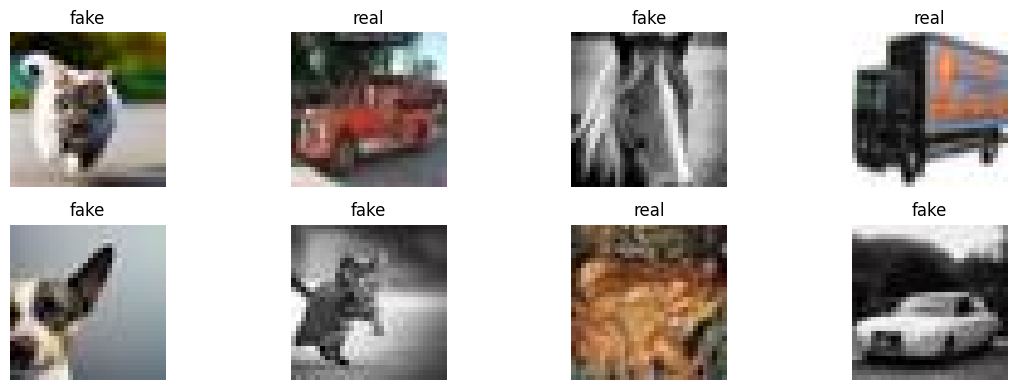

In [38]:
import matplotlib.pyplot as plt

def show_cifake_samples(df, hf_dataset_dict, n=8):
    plt.figure(figsize=(12, 4))

    for i in range(n):
        row = df.iloc[i]
        split = row["hf_split"]
        idx = int(row["hf_index"])

        example = hf_dataset_dict[split][idx]
        img = example["image"]
        label = row["label"]

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_cifake_samples(df_train, ds_cifake, n=8)

In [42]:
import torch
from torch.utils.data import Dataset

class PrecomputedErrorMapDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        x = torch.load(row["map_path"])
        y = torch.tensor(int(row["y"]), dtype=torch.long)

        return x.float(), y

In [78]:
@torch.no_grad()
def compute_unet_error_maps(image_path, timesteps=UNET_TIMESTEPS):
    """
    Sortie : tensor [len(timesteps), 64, 64]
    Exemple : [4, 64, 64]
    """

    image = load_image_tensor(image_path)
    z0 = encode_image_to_latent_unet(image)

    maps = []

    for t in timesteps:
        timestep = torch.tensor([t], device=device, dtype=torch.long)

        noise = torch.randn_like(z0)

        zt = scheduler_unet.add_noise(
            z0,
            noise,
            timestep
        )

        noise_pred = unet(
            zt,
            timestep,
            encoder_hidden_states=text_embeddings_unet
        ).sample

        error_map = torch.abs(noise - noise_pred)  # [1, 4, 64, 64]

        error_map = error_map.mean(dim=1)          # [1, 64, 64]

        maps.append(error_map[0].detach().cpu())

    maps = torch.stack(maps, dim=0)                # [4, 64, 64]

    return maps

In [79]:
def precompute_error_maps(
    df,
    hf_dataset_dict,
    compute_error_map_fn,
    output_dir,
    prefix
):
    """
    Calcule les cartes d'erreur pour chaque image et les sauvegarde en .pt.
    Retourne un nouveau DataFrame avec une colonne map_path.
    """
    os.makedirs(output_dir, exist_ok=True)

    rows = []

    for i, row in tqdm(df.iterrows(), total=len(df), desc=f"Precompute {prefix}"):
        split = row["hf_split"]
        hf_index = int(row["hf_index"])

        example = hf_dataset_dict[split][hf_index]
        img = example["image"].convert("RGB")

        error_maps = compute_error_map_fn(img)  # [C, 64, 64]

        save_name = f"{prefix}_{split}_{hf_index}.pt"
        save_path = os.path.join(output_dir, save_name)

        torch.save(error_maps.cpu(), save_path)

        new_row = row.to_dict()
        new_row["map_path"] = save_path
        rows.append(new_row)

    return pd.DataFrame(rows)

In [51]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

def load_image_tensor(image_input):
    """
    image_input peut être :
    - un chemin vers une image : str
    - une image PIL venant de Hugging Face
    """

    if isinstance(image_input, str):
        img = Image.open(image_input).convert("RGB")

    elif isinstance(image_input, Image.Image):
        img = image_input.convert("RGB")

    else:
        raise TypeError(f"Type non supporté pour image_input : {type(image_input)}")

    x = image_transform(img).unsqueeze(0)

    return x

In [80]:
pipe_unet = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False
).to(device)

pipe_unet.scheduler = DDIMScheduler.from_config(pipe_unet.scheduler.config)

vae_unet = pipe_unet.vae
unet = pipe_unet.unet
tokenizer_unet = pipe_unet.tokenizer
text_encoder_unet = pipe_unet.text_encoder
scheduler_unet = pipe_unet.scheduler

vae_unet.eval()
unet.eval()
text_encoder_unet.eval()

print("Pipeline U-Net chargée")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Pipeline U-Net chargée


In [81]:
UNET_CACHE_DIR = "/content/cifake_error_maps/unet"

df_train_unet = precompute_error_maps(
    df_train,
    ds_cifake,
    compute_unet_error_maps,
    output_dir=UNET_CACHE_DIR,
    prefix="unet_train"
)

df_val_unet = precompute_error_maps(
    df_val,
    ds_cifake,
    compute_unet_error_maps,
    output_dir=UNET_CACHE_DIR,
    prefix="unet_val"
)

df_test_unet = precompute_error_maps(
    df_test,
    ds_cifake,
    compute_unet_error_maps,
    output_dir=UNET_CACHE_DIR,
    prefix="unet_test"
)

Precompute unet_train:   0%|          | 0/2000 [00:00<?, ?it/s]

Precompute unet_val:   0%|          | 0/400 [00:00<?, ?it/s]

Precompute unet_test:   0%|          | 0/100 [00:00<?, ?it/s]

In [82]:
from torch.utils.data import DataLoader

train_dataset_unet = PrecomputedErrorMapDataset(df_train_unet)
val_dataset_unet   = PrecomputedErrorMapDataset(df_val_unet)
test_dataset_unet  = PrecomputedErrorMapDataset(df_test_unet)

train_loader_unet = DataLoader(train_dataset_unet, batch_size=BATCH_SIZE, shuffle=True)
val_loader_unet   = DataLoader(val_dataset_unet, batch_size=BATCH_SIZE, shuffle=False)
test_loader_unet  = DataLoader(test_dataset_unet, batch_size=BATCH_SIZE, shuffle=False)

In [83]:
import torch.nn as nn

class ErrorMapCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64 -> 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 -> 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16 -> 8

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [84]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in tqdm(loader, desc="Train", leave=False):
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total

In [85]:
def evaluate_model(model, loader, criterion, desc="Eval"):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc=desc, leave=False):
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            total_loss += loss.item() * x.size(0)

            correct += (preds == y).sum().item()
            total += y.size(0)

            all_labels.extend(y.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / total
    acc = correct / total

    return avg_loss, acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [86]:
def fit_cnn_model(
    train_loader,
    val_loader,
    in_channels,
    model_name="model",
    epochs=EPOCHS
):
    model = ErrorMapCNN(in_channels=in_channels, num_classes=2).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4
    )

    best_val_acc = 0
    best_state = None
    history = []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs} — {model_name}")

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        val_loss, val_acc, _, _, _ = evaluate_model(
            model,
            val_loader,
            criterion,
            desc="Validation"
        )

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        })

        print(f"Train loss : {train_loss:.4f} | Train acc : {train_acc:.4f}")
        print(f"Val loss   : {val_loss:.4f} | Val acc   : {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()
            print("Meilleur modèle sauvegardé.")

    model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

In [87]:
def final_test(model, test_loader, method_name="method"):
    criterion = nn.CrossEntropyLoss()

    test_loss, test_acc, y_true, y_pred, y_prob = evaluate_model(
        model,
        test_loader,
        criterion,
        desc="Test"
    )

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = np.nan

    print("=" * 60)
    print(method_name)
    print("=" * 60)

    print("Test loss :", test_loss)
    print("Test acc  :", test_acc)
    print("Precision :", precision)
    print("Recall    :", recall)
    print("F1-score  :", f1)
    print("AUC       :", auc)

    print("\nMatrice de confusion :")
    print(confusion_matrix(y_true, y_pred))

    print("\nRapport de classification :")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["real", "fake"],
        zero_division=0
    ))

    results = {
        "method": method_name,
        "test_loss": test_loss,
        "accuracy": test_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }

    return results, y_true, y_pred, y_prob

In [88]:
model_unet, history_unet = fit_cnn_model(
    train_loader=train_loader_unet,
    val_loader=val_loader_unet,
    in_channels=len(UNET_TIMESTEPS),
    model_name="CNN sur cartes U-Net",
    epochs=15
)


Epoch 1/15 — CNN sur cartes U-Net


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Train loss : 0.5037 | Train acc : 0.7570
Val loss   : 0.5065 | Val acc   : 0.7400
Meilleur modèle sauvegardé.

Epoch 2/15 — CNN sur cartes U-Net


Train:   0%|          | 0/250 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Train loss : 0.0487 | Train acc : 0.9875
Val loss   : 1.3965 | Val acc   : 0.6925

Epoch 15/15 — CNN sur cartes U-Net


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Train loss : 0.0581 | Train acc : 0.9820
Val loss   : 1.0177 | Val acc   : 0.7075


In [89]:
results_unet, y_true_unet, y_pred_unet, y_prob_unet = final_test(
    model_unet,
    test_loader_unet,
    method_name="U-Net multi-t + CNN"
)

Test:   0%|          | 0/13 [00:00<?, ?it/s]

U-Net multi-t + CNN
Test loss : 1.0478086519241332
Test acc  : 0.67
Precision : 0.6075949367088608
Recall    : 0.96
F1-score  : 0.7441860465116279
AUC       : 0.864

Matrice de confusion :
[[19 31]
 [ 2 48]]

Rapport de classification :
              precision    recall  f1-score   support

        real       0.90      0.38      0.54        50
        fake       0.61      0.96      0.74        50

    accuracy                           0.67       100
   macro avg       0.76      0.67      0.64       100
weighted avg       0.76      0.67      0.64       100



In [90]:
del pipe_unet
del vae_unet
del unet
del tokenizer_unet
del text_encoder_unet
del scheduler_unet

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Mémoire U-Net libérée")

Mémoire U-Net libérée


In [91]:
pipe_lcm = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False
).to(device)

pipe_lcm.scheduler = LCMScheduler.from_config(pipe_lcm.scheduler.config)

pipe_lcm.load_lora_weights(LCM_LORA_ID)
pipe_lcm.fuse_lora()

vae_lcm = pipe_lcm.vae
unet_lcm = pipe_lcm.unet
tokenizer_lcm = pipe_lcm.tokenizer
text_encoder_lcm = pipe_lcm.text_encoder
scheduler_lcm = pipe_lcm.scheduler

vae_lcm.eval()
unet_lcm.eval()
text_encoder_lcm.eval()

print("Pipeline LCM chargée")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Pipeline LCM chargée


In [92]:
@torch.no_grad()
def get_text_embeddings_lcm(prompt=PROMPT):
    text_inputs = tokenizer_lcm(
        [prompt],
        padding="max_length",
        max_length=tokenizer_lcm.model_max_length,
        truncation=True,
        return_tensors="pt"
    )

    input_ids = text_inputs.input_ids.to(device)
    text_embeddings = text_encoder_lcm(input_ids)[0]

    return text_embeddings


@torch.no_grad()
def encode_image_to_latent_lcm(image_tensor):
    image_tensor = image_tensor.to(device=device, dtype=dtype)

    latent_dist = vae_lcm.encode(image_tensor).latent_dist
    z0 = latent_dist.sample()
    z0 = z0 * vae_lcm.config.scaling_factor

    return z0


text_embeddings_lcm = get_text_embeddings_lcm(PROMPT)

In [93]:
@torch.no_grad()
def compute_lcm_error_maps(image_path, num_steps=LCM_NUM_STEPS):
    """
    Sortie : tensor [num_steps, 64, 64]
    Exemple : [4, 64, 64]
    """

    image = load_image_tensor(image_path)
    z0 = encode_image_to_latent_lcm(image)

    scheduler_lcm.set_timesteps(num_steps, device=device)
    timesteps = scheduler_lcm.timesteps

    first_t = timesteps[0]

    noise = torch.randn_like(z0)

    sample = scheduler_lcm.add_noise(
        z0,
        noise,
        first_t.reshape(1)
    )

    maps = []

    for t in timesteps:
        timestep = t.reshape(1).to(device)

        model_output = unet_lcm(
            sample,
            timestep,
            encoder_hidden_states=text_embeddings_lcm
        ).sample

        step_output = scheduler_lcm.step(
            model_output=model_output,
            timestep=t,
            sample=sample,
            return_dict=True
        )

        if hasattr(step_output, "denoised") and step_output.denoised is not None:
            z0_hat = step_output.denoised
        elif hasattr(step_output, "pred_original_sample"):
            z0_hat = step_output.pred_original_sample
        else:
            raise ValueError("Impossible de récupérer z0_hat depuis le scheduler LCM.")

        error_map = torch.abs(z0 - z0_hat)  # [1, 4, 64, 64]

        error_map = error_map.mean(dim=1)   # [1, 64, 64]

        maps.append(error_map[0].detach().cpu())

        sample = step_output.prev_sample

    maps = torch.stack(maps, dim=0)          # [4, 64, 64]

    return maps

In [94]:
LCM_CACHE_DIR = "/content/cifake_error_maps/lcm"

df_train_lcm = precompute_error_maps(
    df_train,
    ds_cifake,
    compute_lcm_error_maps,
    output_dir=LCM_CACHE_DIR,
    prefix="lcm_train"
)

df_val_lcm = precompute_error_maps(
    df_val,
    ds_cifake,
    compute_lcm_error_maps,
    output_dir=LCM_CACHE_DIR,
    prefix="lcm_val"
)

df_test_lcm = precompute_error_maps(
    df_test,
    ds_cifake,
    compute_lcm_error_maps,
    output_dir=LCM_CACHE_DIR,
    prefix="lcm_test"
)

Precompute lcm_train:   0%|          | 0/2000 [00:00<?, ?it/s]

Precompute lcm_val:   0%|          | 0/400 [00:00<?, ?it/s]

Precompute lcm_test:   0%|          | 0/100 [00:00<?, ?it/s]

In [95]:
train_dataset_lcm = PrecomputedErrorMapDataset(df_train_lcm)
val_dataset_lcm   = PrecomputedErrorMapDataset(df_val_lcm)
test_dataset_lcm  = PrecomputedErrorMapDataset(df_test_lcm)

train_loader_lcm = DataLoader(train_dataset_lcm, batch_size=BATCH_SIZE, shuffle=True)
val_loader_lcm   = DataLoader(val_dataset_lcm, batch_size=BATCH_SIZE, shuffle=False)
test_loader_lcm  = DataLoader(test_dataset_lcm, batch_size=BATCH_SIZE, shuffle=False)

In [103]:
model_lcm, history_lcm = fit_cnn_model(
    train_loader=train_loader_lcm,
    val_loader=val_loader_lcm,
    in_channels=LCM_NUM_STEPS,
    model_name="CNN sur cartes LCM",
    epochs=15
)


Epoch 1/15 — CNN sur cartes LCM


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Train loss : 0.6440 | Train acc : 0.6285
Val loss   : 0.6731 | Val acc   : 0.6325
Meilleur modèle sauvegardé.

Epoch 2/15 — CNN sur cartes LCM


Train:   0%|          | 0/250 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Train loss : 0.1442 | Train acc : 0.9510
Val loss   : 0.7064 | Val acc   : 0.6775

Epoch 15/15 — CNN sur cartes LCM


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Validation:   0%|          | 0/50 [00:00<?, ?it/s]

Train loss : 0.1400 | Train acc : 0.9520
Val loss   : 0.8134 | Val acc   : 0.6525


In [104]:
results_lcm, y_true_lcm, y_pred_lcm, y_prob_lcm = final_test(
    model_lcm,
    test_loader_lcm,
    method_name="LCM + CNN"
)

Test:   0%|          | 0/13 [00:00<?, ?it/s]

LCM + CNN
Test loss : 0.5160291451215744
Test acc  : 0.8
Precision : 0.8125
Recall    : 0.78
F1-score  : 0.7959183673469388
AUC       : 0.8712

Matrice de confusion :
[[41  9]
 [11 39]]

Rapport de classification :
              precision    recall  f1-score   support

        real       0.79      0.82      0.80        50
        fake       0.81      0.78      0.80        50

    accuracy                           0.80       100
   macro avg       0.80      0.80      0.80       100
weighted avg       0.80      0.80      0.80       100



In [105]:
df_compare = pd.DataFrame([
    results_unet,
    results_lcm
])

display(df_compare)

,method,test_loss,accuracy,precision,recall,f1,auc
0,U-Net multi-t + CNN,1.047809,0.67,0.607595,0.96,0.744186,0.8640
1,LCM + CNN,0.516029,0.80,0.812500,0.78,0.795918,0.8712


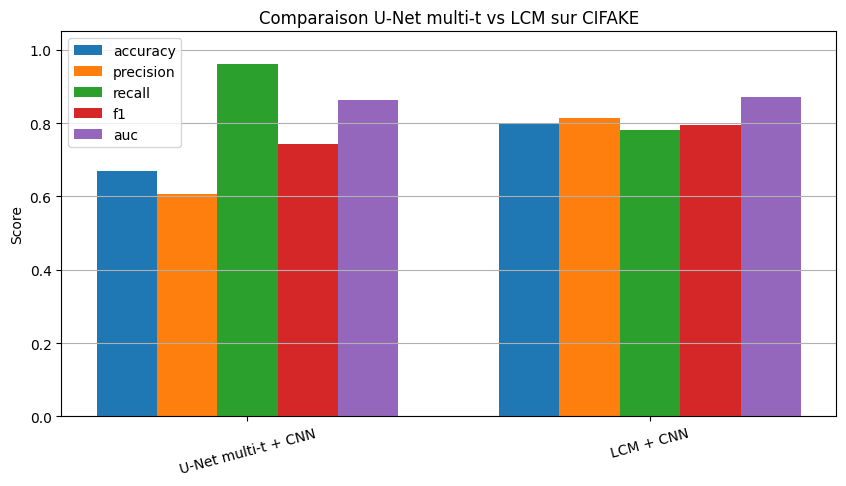

In [106]:
metrics = ["accuracy", "precision", "recall", "f1", "auc"]

plt.figure(figsize=(10, 5))

x = np.arange(len(df_compare["method"]))
width = 0.15

for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        df_compare[metric],
        width,
        label=metric
    )

plt.xticks(x + width * 2, df_compare["method"], rotation=15)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Comparaison U-Net multi-t vs LCM sur CIFAKE")
plt.legend()
plt.grid(axis="y")
plt.show()